# b1 graph + what has been annotated (in pink)

In [1]:
import sqlite3
import pandas as pd
from tqdm import tqdm
import powerlaw as pwl
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np


In [2]:
con = sqlite3.connect("vp_data2_isikud.db")
cur = con.cursor()
cur.execute('ATTACH DATABASE "v33.db" AS v33')

In [30]:
query = """

SELECT *
from 
transactions_verbs_obl_kohakaandes_root_counts_distinct_coverage_v2_wcomps as cover
where annotated=='true'
order by root_count desc
"""

s = pd.read_sql_query(query, con)

In [31]:
len(s)

10555

## base tabel kus on verb, kääne, elus_cnt, koht_cnt, distinct root count  

In [32]:
query = """

SELECT distinct
base.verb as verb,
base.verb_compound as verb_compound,
base.kaane as kaane,
base.elus_cnt as elus_cnt,
base.koht_cnt as koht_cnt,
base.root_cnt as root_cnt,
cover.annotated as annotated

from 

transactions_verbs_obl_kohakaandes_eluskoht_root_counts_distinct_base_wcomps_v1 as base
left join
transactions_verbs_obl_kohakaandes_root_counts_distinct_coverage_v2_wcomps as cover
on base.verb=cover.verb
and base.verb_compound = cover.verb_compound
and base.root_cnt = cover.root_count
and base.kaane = cover.kaane
"""

source3 = pd.read_sql_query(query, con)
#source3

In [33]:
source3["elus_div"] = source3["elus_cnt"]/source3["root_cnt"]
source3["koht_div"] = source3["koht_cnt"]/source3["root_cnt"]

source3["kaane2"] = ''

source3.loc[source3['kaane'] == 'ill', 'kaane2'] = 'sisse'
source3.loc[source3['kaane'] == 'in', 'kaane2'] = 'sees'
source3.loc[source3['kaane'] == 'el', 'kaane2'] = 'seest'
source3.loc[source3['kaane'] == 'all', 'kaane2'] = 'alale'
source3.loc[source3['kaane'] == 'ad', 'kaane2'] = 'alal'
source3.loc[source3['kaane'] == 'abl', 'kaane2'] = 'alalt'
source3.loc[source3['kaane'] == 'adit', 'kaane2'] = 'sisse'

In [34]:
source3

,verb,verb_compound,kaane,elus_cnt,koht_cnt,root_cnt,annotated,elus_div,koht_div,kaane2
0,saama,,el,1274,402,19632,true,0.064894,0.020477,seest
1,andma,,all,1601,250,11612,true,0.137875,0.021529,alale
2,rääkima,,el,802,202,10891,true,0.073639,0.018547,seest
3,saama,,in,134,306,8532,true,0.015706,0.035865,sees
4,tulema,,ad,1134,166,8468,true,0.133916,0.019603,alal
...,...,...,...,...,...,...,...,...,...,...
74715,šveitsima,,el,0,0,1,false,0.000000,0.000000,seest
74716,švipsima,,ad,0,0,1,false,0.000000,0.000000,alal
74717,žestikuleerima,,ad,0,1,1,false,0.000000,1.000000,alal
74718,žisraelima,,ad,0,0,1,false,0.000000,0.000000,alal


### normaliseeritud väärtustega pilt

### filter 1: root_cnt >=100

In [35]:
# mummude suurus
areadict = {}
root_cnts = sorted(list(set(list(source3["root_cnt"])))) # 1-21K

for cnt in root_cnts:
    if cnt <10: areadict[cnt] = 1
    elif cnt >=10 and cnt < 100: areadict[cnt] = 5
    elif cnt >=100 and cnt < 500: areadict[cnt] = 10
    elif cnt >=500 and cnt < 1000: areadict[cnt] = 30
    elif cnt >=1000 and cnt < 2000: areadict[cnt] = 50
    elif cnt >=2000 and cnt < 5000: areadict[cnt] = 80
    elif cnt >=5000 and cnt < 10000: areadict[cnt] = 100
    elif cnt >=10000 and cnt < 15000: areadict[cnt] = 300
    elif cnt >=15000 and cnt < 20000: areadict[cnt] = 500
    elif cnt >=20000: areadict[cnt] = 700


# andmed
#elusad = []
#kohad = []
#roots = []

#for i in range(len(source2)):
#    if source2.iloc[i]["root_cnt"]>=100:
#        roots.append(source2.iloc[i]["root_cnt"])
#        kohad.append(source2.iloc[i]["koht_cnt"]/source2.iloc[i]["root_cnt"])
#        elusad.append(source2.iloc[i]["elus_cnt"]/source2.iloc[i]["root_cnt"])
              

In [36]:
r100 = source3[source3["root_cnt"]>=100]

In [37]:
#koht_kindlam = r100[(r100["elus_div"]<=0.05) & (r100["koht_div"]>=0.2)]
koht_kindlam = r100[(r100["elus_div"]<=0.1) & (r100["koht_div"]>=0.2)]
koht_kindlam_root_cnt = list(koht_kindlam["root_cnt"])
koht_kindlam_koht_cnt = list(koht_kindlam["koht_div"])
koht_kindlam_elus_cnt = list(koht_kindlam["elus_div"])


koht_maybe = r100[(r100["elus_div"]<=0.05) & (r100["koht_div"]>=0.1) & (r100["koht_div"]<0.2)]
koht_maybe_root_cnt = list(koht_maybe["root_cnt"])
koht_maybe_koht_cnt = list(koht_maybe["koht_div"])
koht_maybe_elus_cnt = list(koht_maybe["elus_div"])


koht_maybe2 = r100[(r100["elus_div"]<=0.05) & (r100["koht_div"]>=0.06) & (r100["koht_div"]<0.1)]
koht_maybe_root_cnt2 = list(koht_maybe2["root_cnt"])
koht_maybe_koht_cnt2 = list(koht_maybe2["koht_div"])
koht_maybe_elus_cnt2 = list(koht_maybe2["elus_div"])

# 2:1 suhe ka kui >=0.15, 0.17 parem kuna on rohkem 3:1?
koht_maybe3 = r100[(r100["elus_div"]>0.05) & (r100["elus_div"]<=0.097) & (r100["koht_div"]>=0.15) & (r100["koht_div"]<0.2)]
koht_maybe_root_cnt3 = list(koht_maybe3["root_cnt"])
koht_maybe_koht_cnt3 = list(koht_maybe3["koht_div"])
koht_maybe_elus_cnt3 = list(koht_maybe3["elus_div"])

# 2:1 suhe rohkem
koht_maybe4 = r100[(r100["elus_div"]>0.05) & (r100["elus_div"]<=0.097) & (r100["koht_div"]>=0.1) & (r100["koht_div"]<0.15)]
koht_maybe_root_cnt4 = list(koht_maybe4["root_cnt"])
koht_maybe_koht_cnt4 = list(koht_maybe4["koht_div"])
koht_maybe_elus_cnt4 = list(koht_maybe4["elus_div"])

In [38]:
elus_kindlam = r100[(r100["elus_div"]>=0.3) & (r100["koht_div"]<=0.1)]
elus_kindlam_root_cnt = list(elus_kindlam["root_cnt"])
elus_kindlam_koht_cnt = list(elus_kindlam["koht_div"])
elus_kindlam_elus_cnt = list(elus_kindlam["elus_div"])

elus_maybe = r100[(r100["elus_div"]>=0.15) & (r100["elus_div"]<0.3) & (r100["koht_div"]<=0.05)]
elus_maybe_root_cnt = list(elus_maybe["root_cnt"])
elus_maybe_koht_cnt = list(elus_maybe["koht_div"])
elus_maybe_elus_cnt = list(elus_maybe["elus_div"])

elus_maybe2 = r100[(r100["elus_div"]>=0.15) & (r100["elus_div"]<0.3) & (r100["koht_div"]>0.05)& (r100["koht_div"]<=0.1)]
elus_maybe_root_cnt2 = list(elus_maybe2["root_cnt"])
elus_maybe_koht_cnt2 = list(elus_maybe2["koht_div"])
elus_maybe_elus_cnt2 = list(elus_maybe2["elus_div"])

elus_maybe3 = r100[(r100["elus_div"]>=0.1) & (r100["elus_div"]<0.15) & (r100["koht_div"]<0.06)]
elus_maybe_root_cnt3 = list(elus_maybe3["root_cnt"])
elus_maybe_koht_cnt3 = list(elus_maybe3["koht_div"])
elus_maybe_elus_cnt3 = list(elus_maybe3["elus_div"])

In [39]:
df_all100 = r100.merge(koht_kindlam.drop_duplicates(), on=list(r100.columns), 
                   how='left', indicator=True)
df_all100 = df_all100[df_all100['_merge'] == 'left_only']
df_all100 = df_all100.drop(columns=["_merge"],axis=1)
df_all100 = df_all100.merge(koht_maybe.drop_duplicates(), on=list(r100.columns), 
                   how='left', indicator=True)
df_all100 = df_all100[df_all100['_merge'] == 'left_only']
df_all100 = df_all100.drop(columns=["_merge"],axis=1)
df_all100 = df_all100.merge(koht_maybe2.drop_duplicates(), on=list(r100.columns), 
                   how='left', indicator=True)
df_all100 = df_all100[df_all100['_merge'] == 'left_only']
df_all100 = df_all100.drop(columns=["_merge"],axis=1)
df_all100 = df_all100.merge(koht_maybe3.drop_duplicates(), on=list(r100.columns), 
                   how='left', indicator=True)
df_all100 = df_all100[df_all100['_merge'] == 'left_only']
df_all100 = df_all100.drop(columns=["_merge"],axis=1)
df_all100 = df_all100.merge(koht_maybe4.drop_duplicates(), on=list(r100.columns), 
                   how='left', indicator=True)
df_all100 = df_all100[df_all100['_merge'] == 'left_only']
df_all100 = df_all100.drop(columns=["_merge"],axis=1)

df_all100 = df_all100.merge(elus_kindlam.drop_duplicates(), on=list(r100.columns), 
                   how='left', indicator=True)
df_all100 = df_all100[df_all100['_merge'] == 'left_only']
df_all100 = df_all100.drop(columns=["_merge"],axis=1)
df_all100 = df_all100.merge(elus_maybe.drop_duplicates(), on=list(r100.columns), 
                   how='left', indicator=True)
df_all100 = df_all100[df_all100['_merge'] == 'left_only']
df_all100 = df_all100.drop(columns=["_merge"],axis=1)
df_all100 = df_all100.merge(elus_maybe2.drop_duplicates(), on=list(r100.columns), 
                   how='left', indicator=True)
df_all100 = df_all100[df_all100['_merge'] == 'left_only']
df_all100 = df_all100.drop(columns=["_merge"],axis=1)
df_all100 = df_all100.merge(elus_maybe3.drop_duplicates(), on=list(r100.columns), 
                   how='left', indicator=True)
df_all100 = df_all100[df_all100['_merge'] == 'left_only']
df_all100 = df_all100.drop(columns=["_merge"],axis=1)

#### juurde need, mille suhe on 3:1 aga div on madal

In [40]:
veel_elusad = df_all100[(df_all100["elus_cnt"]>=3*df_all100["koht_cnt"])&(df_all100["elus_div"]<0.1)]
veel_elusad_root_cnt = list(veel_elusad["root_cnt"])
veel_elusad_koht_cnt = list(veel_elusad["koht_div"])
veel_elusad_elus_cnt = list(veel_elusad["elus_div"])

veel_kohad = df_all100[(df_all100["koht_cnt"]>=3*df_all100["elus_cnt"])&(df_all100["elus_div"]<0.05)]
veel_kohad_root_cnt = list(veel_kohad["root_cnt"])
veel_kohad_koht_cnt = list(veel_kohad["koht_div"])
veel_kohad_elus_cnt = list(veel_kohad["elus_div"])

In [41]:
df_all100 = df_all100.merge(veel_elusad.drop_duplicates(), on=list(r100.columns), 
                   how='left', indicator=True)
df_all100 = df_all100[df_all100['_merge'] == 'left_only']
df_all100 = df_all100.drop(columns=["_merge"],axis=1)
df_all100 = df_all100.merge(veel_kohad.drop_duplicates(), on=list(r100.columns), 
                   how='left', indicator=True)
df_all100 = df_all100[df_all100['_merge'] == 'left_only']
df_all100 = df_all100.drop(columns=["_merge"],axis=1)

In [42]:
# mis punktid jäävad alles
df_all100

,verb,verb_compound,kaane,elus_cnt,koht_cnt,root_cnt,annotated,elus_div,koht_div,kaane2
0,saama,,in,134,306,8532,true,0.015706,0.035865,sees
1,tulema,,el,425,266,7831,true,0.054271,0.033968,seest
4,jääma,,el,534,200,6297,true,0.084802,0.031761,seest
5,tegema,,in,97,268,5828,true,0.016644,0.045985,sees
6,tulema,,in,87,244,5535,true,0.015718,0.044083,sees
...,...,...,...,...,...,...,...,...,...,...
1184,jutlustama,,el,8,8,100,true,0.080000,0.080000,seest
1185,külvama,,in,15,21,100,true,0.150000,0.210000,sees
1188,täpsustama,,ad,2,5,100,true,0.020000,0.050000,alal
1189,valama,,el,6,3,100,true,0.060000,0.030000,seest


In [43]:
roots = list(df_all100["root_cnt"])
kohad =  list(df_all100["koht_div"])
elusad = list(df_all100["elus_div"])

In [44]:
# mis on annoteeritud
anns = source3[(source3["annotated"]=='true') & (source3["root_cnt"]>=100)]

ann_roots = list(anns["root_cnt"])
ann_kohad =  list(anns["koht_div"])
ann_elusad = list(anns["elus_div"])


In [45]:
# annoteerimata 100+ root_cnt kirjeid ei ole
source3[(source3["annotated"]=='false') & (source3["root_cnt"]>=100)]

,verb,verb_compound,kaane,elus_cnt,koht_cnt,root_cnt,annotated,elus_div,koht_div,kaane2


ROHELINE - üsna kindlalt 
KOLLANE - suure tõenäosusega 
ORANŽ - maybe
PUNANE - liiga küsitav
ROOSA - annoteeritud
Kiired:
PUNANE - 45
ÜLEJÄÄNUD - 3:1, 2:1 ja 1.5:1 jooned
Roheline - kohtade puhul veel rangem piir


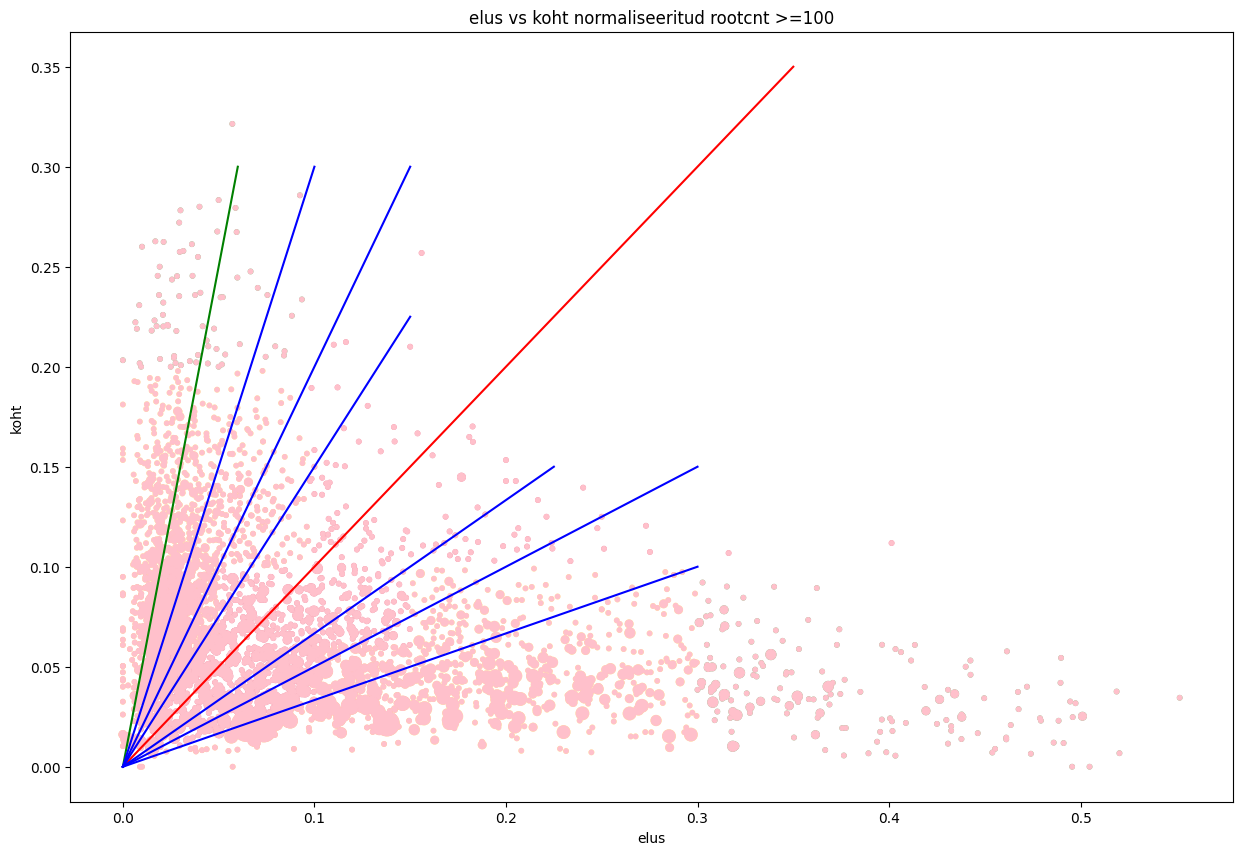

In [46]:
plt.figure(figsize=(15, 10))

# 45 kraadine joon: mitteinformatiivsed punktid
plt.plot([0, 0.35], [0, 0.35], c='red')


# kiir 1: koht kindlamad näited
#plt.plot([0, 0.05*1.2], [0, 0.25*1.2], c='blue')

# kiir 2: koht vähem kindlamad näited
#plt.plot([0, 0.12], [0, 0.25], c='blue')

# kiir 3: elus kindlamad näited
#plt.plot([0, 0.3*1.3], [0, 0.1*1.3], c='blue')

# kiir 4: elus vähem kindlamad näited
#plt.plot([0, 0.2*1.3], [0, 0.1*1.3], c='blue')

# kiir 5: alumine cutoff
#plt.plot([0, 0.06], [0.04, 0], c='blue')


# kiir : koht kindlamad näited
plt.plot([0, 0.05*1.2], [0, 0.25*1.2], c='green')

# kiir 1: koht 3:1
plt.plot([0, 0.1], [0, 0.3], c='blue')

# kiir 2: koht 2:1
plt.plot([0, 0.1*1.5], [0, 0.2*1.5], c='blue')

# kiir 3: koht 1.5:1
plt.plot([0, 0.1*1.5], [0, 0.15*1.5], c='blue')


# kiir 4: elus 3:1
plt.plot([0, 0.3], [0, 0.1], c='blue')

# kiir 5: elus 2:1
plt.plot([0, 0.2*1.5], [0, 0.1*1.5], c='blue')

# kiir 6: elus 1.5:1
plt.plot([0, 0.15*1.5], [0, 0.1*1.5], c='blue')

# kõik punktid
x = elusad
y = kohad
#N = len(source3)
#colors = np.random.rand(N)
area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.5)


# koht kindlamalt
x = koht_kindlam_elus_cnt
y = koht_kindlam_koht_cnt
area = [areadict[cnt] for cnt in koht_kindlam_root_cnt]
plt.scatter(x, y, s=area, c='green', alpha=0.5)


# koht maybe
x = koht_maybe_elus_cnt
y = koht_maybe_koht_cnt
area = [areadict[cnt] for cnt in koht_maybe_root_cnt]
plt.scatter(x, y, s=area, c='yellow', alpha=0.5)


x = koht_maybe_elus_cnt2
y = koht_maybe_koht_cnt2
area = [areadict[cnt] for cnt in koht_maybe_root_cnt2]
plt.scatter(x, y, s=area, c='orange', alpha=0.5)

x = koht_maybe_elus_cnt3
y = koht_maybe_koht_cnt3
area = [areadict[cnt] for cnt in koht_maybe_root_cnt3]
plt.scatter(x, y, s=area, c='yellow', alpha=0.5)

x = koht_maybe_elus_cnt4
y = koht_maybe_koht_cnt4
area = [areadict[cnt] for cnt in koht_maybe_root_cnt4]
plt.scatter(x, y, s=area, c='orange', alpha=0.5)


# elus kindlam
x = elus_kindlam_elus_cnt
y = elus_kindlam_koht_cnt
area = [areadict[cnt] for cnt in elus_kindlam_root_cnt]
plt.scatter(x, y, s=area, c='green', alpha=0.5)

# elus maybe
x = elus_maybe_elus_cnt
y = elus_maybe_koht_cnt
area = [areadict[cnt] for cnt in elus_maybe_root_cnt]
plt.scatter(x, y, s=area, c='yellow', alpha=0.5)

x = elus_maybe_elus_cnt2
y = elus_maybe_koht_cnt2
area = [areadict[cnt] for cnt in elus_maybe_root_cnt2]
plt.scatter(x, y, s=area, c='yellow', alpha=0.5)

x = elus_maybe_elus_cnt3
y = elus_maybe_koht_cnt3
area = [areadict[cnt] for cnt in elus_maybe_root_cnt3]
plt.scatter(x, y, s=area, c='orange', alpha=0.5)

# veel
x = veel_elusad_elus_cnt
y = veel_elusad_koht_cnt
area = [areadict[cnt] for cnt in veel_elusad_root_cnt]
plt.scatter(x, y, s=area, c='orange', alpha=0.5)

x = veel_kohad_elus_cnt
y = veel_kohad_koht_cnt
area = [areadict[cnt] for cnt in veel_kohad_root_cnt]
plt.scatter(x, y, s=area, c='orange', alpha=0.5)


# annoteeritud verbid
x = ann_elusad
y = ann_kohad
area = [areadict[cnt] for cnt in ann_roots] #[10]*len(ann_roots) #
plt.scatter(x, y, s=area, c='pink')#, alpha=0.5)


plt.title("elus vs koht normaliseeritud rootcnt >=100")
plt.ylabel("koht")
plt.xlabel("elus")

print("ROHELINE - üsna kindlalt \nKOLLANE - suure tõenäosusega \nORANŽ - maybe\nPUNANE - liiga küsitav\nROOSA - annoteeritud")
print("Kiired:\nPUNANE - 45\nÜLEJÄÄNUD - 3:1, 2:1 ja 1.5:1 jooned\nRoheline - kohtade puhul veel rangem piir")

plt.show()

In [1]:
con.close()

NameError: name 'con' is not defined